# General Relativity and the Precession of Mercury

Newton's law of gravity predicts that a lone planet traces a *closed* ellipse:
the point of closest approach to the Sun, the **perihelion**, sits at a fixed
angle and never moves. Mercury does not obey this. Its perihelion slowly rotates,
or **precesses**, around the Sun. Most of that precession is explained by tugs
from the other planets, but a stubborn residue of about **43 arcseconds per
century** refused to yield to Newtonian mechanics for decades. In 1915 Einstein's
general theory of relativity accounted for that residue exactly, and it became one
of the first great confirmations of the theory.

We cannot integrate the full curved-spacetime equations of motion here, but we can
capture the *leading* general-relativity correction with a small, physically
motivated change to the force law. General relativity effectively multiplies the
Newtonian inverse-square attraction by a factor that grows as the planet nears the
Sun:

$$F(r) \;\propto\; \frac{1}{r^2}\left(1 + \frac{\alpha}{r^2}\right).$$

The extra $1/r^4$ term is tiny at Mercury's distance, but it breaks the perfect
$1/r^2$ symmetry that makes Newtonian ellipses close. The orbit no longer returns
to exactly the same orientation each revolution, and the perihelion creeps forward.

This notebook has two parts:

1. **Watch the precession.** We integrate Mercury's orbit for a single,
   deliberately exaggerated value of $\alpha$ so the perihelion drift is visible to
   the eye, and we measure the drift rate in degrees per year.
2. **Extrapolate to the real value.** We sweep $\alpha$ over a range, confirm the
   drift rate is *linear* in $\alpha$, and extrapolate down to the physical
   Schwarzschild value $\alpha_{\mathrm{GR}}$ derived from first principles. That
   gives an estimate of Mercury's precession in **arcseconds per century**, which
   we compare against the famous 43.

Everything the notebook needs is defined locally, so it runs stand-alone.

---
## Why a symplectic integrator?

The precession we are chasing is *slow*: the perihelion barely moves from one orbit
to the next. That makes the measurement extremely sensitive to numerical error. An
ordinary integrator (even a high-order one like Runge-Kutta) does not exactly
conserve energy - it slowly gains or loses it. In an orbit, a drifting energy shows
up as a drifting orbit shape, which looks *exactly* like precession. A non-conserving
method would therefore manufacture a fake precession on top of the real one, and we
would have no way to tell them apart.

**Symplectic** integrators solve this. They are built to respect the geometric
structure of Hamiltonian mechanics, so their energy error stays *bounded* forever
instead of drifting. We use the **Yoshida 4th-order** symplectic method (the same
one studied in `pendulums.ipynb`), which composes three leapfrog substeps per step
with carefully chosen weights - one of them stepping *backward* in time - to cancel
the lower-order error. With energy locked in, any perihelion drift we measure is the
genuine effect of the modified force law, not a numerical artifact.

The next cell defines the physical constants (converted from SI into astronomical
units and Julian years), the Yoshida coefficients, and the GR-corrected acceleration.

In [1]:
"""general_relativity.ipynb"""

# Cell 01 - Imports, constants, and the GR-corrected acceleration

%matplotlib inline

from math import ceil

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# Physical constants (SI, then combined into AU / Julian-year units)
m_sun = 1.98847e30  # mass of the Sun (kg)
G = 6.67430e-11  # gravitational constant (m^3 kg^-1 s^-2)
year_s = 3.15576e7  # seconds in a Julian year
AU = 1.495978707e11  # astronomical unit (m)

# Standard gravitational parameter of the Sun, expressed in AU^3 / yr^2.
# Working in these units keeps Mercury's numbers close to order 1.
GM = G * m_sun * year_s**2 / AU**3


def yoshida_coeffs():
    """Position (c) and velocity (d) substep coefficients for Yoshida 4th order.

    From Yoshida (1990), "Construction of higher order symplectic integrators."
    The middle substep uses a negative weight, stepping backward in time to
    cancel the leading error of a single leapfrog step.
    """
    cbrt2 = 2.0 ** (1.0 / 3.0)
    w1 = 1.0 / (2.0 - cbrt2)
    w0 = -cbrt2 / (2.0 - cbrt2)
    c = np.array([w1 / 2.0, (w0 + w1) / 2.0, (w0 + w1) / 2.0, w1 / 2.0])
    d = np.array([w1, w0, w1])
    return c, d


def accel(xv, yv, alpha):
    """GR-corrected gravitational acceleration on Mercury.

    Multiplies the Newtonian inverse-square acceleration by (1 + alpha / r^2),
    which adds a 1/r^4 perturbation mimicking the leading general-relativity
    correction. Returns the (ax, ay) components in AU/yr^2.
    """
    rv = np.hypot(xv, yv)
    corr = 1.0 + alpha / rv**2
    ax = -GM * xv / rv**3 * corr
    ay = -GM * yv / rv**3 * corr
    return ax, ay


# Quick check that the constants and helpers are sensible
c_coeffs, d_coeffs = yoshida_coeffs()
print(f"GM (Sun)        = {GM:.4f} AU^3/yr^2")
print(f"Yoshida c       = {np.round(c_coeffs, 4)}  (sums to {c_coeffs.sum():.3f})")
print(f"Yoshida d       = {np.round(d_coeffs, 4)}  (sums to {d_coeffs.sum():.3f})")
ax0, ay0 = accel(0.47, 0.0, 0.0)
print(f"accel(0.47 AU)  = {ax0:+.3f} AU/yr^2 (Newtonian, points toward Sun)")

GM (Sun)        = 39.4781 AU^3/yr^2
Yoshida c       = [ 0.6756 -0.1756 -0.1756  0.6756]  (sums to 1.000)
Yoshida d       = [ 1.3512 -1.7024  1.3512]  (sums to 1.000)
accel(0.47 AU)  = -178.715 AU/yr^2 (Newtonian, points toward Sun)


---
## The orbit integrator

The next cell wraps the Yoshida integration in a single function,
`simulate_orbit(alpha, tf)`, so both parts of the notebook can reuse it. It starts
Mercury at perihelion on the $+x$ axis ($x_0 = a = 0.47\ \text{AU}$) moving purely
in the $+y$ direction at $8.2\ \text{AU/yr}$, then steps forward with an hourly time
step. At each step it records the position $(x, y)$ and the distance $r$ from the Sun.

A companion function `find_perihelia` locates every perihelion (each local *minimum*
of $r$, found as a peak of $-r$) and reports the angle of the Sun-Mercury line at
those instants. Because that angle marches steadily past $360°$ we **unwrap** it, so
a smooth line rather than a saw-tooth comes out - the slope of that line is the
precession rate we want.

In [2]:
# Cell 02 - Orbit integrator and perihelion finder


def simulate_orbit(alpha, tf=2.0):
    """Integrate Mercury's orbit under the GR-corrected force for tf Julian years.

    Uses the Yoshida 4th-order symplectic integrator with an hourly time step.
    Returns the time, position, and distance arrays (t, x, y, r).
    """
    n = ceil(tf * 365.25 * 24)  # one sample per hour
    dt = tf / n  # time step (Julian years)

    a_merc = 0.47  # Mercury semi-major axis (AU)

    t = np.arange(n) * dt
    x = np.empty(n)
    y = np.empty(n)
    vx = np.empty(n)
    vy = np.empty(n)
    r = np.empty(n)

    # Initial conditions: start at perihelion on the +x axis, moving in +y
    x[0], y[0] = a_merc, 0.0
    vx[0], vy[0] = 0.0, 8.2  # AU/yr
    r[0] = np.hypot(x[0], y[0])

    c, d = yoshida_coeffs()

    for i in range(1, n):
        px, py = x[i - 1], y[i - 1]
        pvx, pvy = vx[i - 1], vy[i - 1]
        # Three Yoshida substeps (drift, kick) then a final drift
        for j in range(3):
            px += c[j] * pvx * dt
            py += c[j] * pvy * dt
            axj, ayj = accel(px, py, alpha)
            pvx += d[j] * axj * dt
            pvy += d[j] * ayj * dt
        px += c[3] * pvx * dt
        py += c[3] * pvy * dt
        x[i], y[i] = px, py
        vx[i], vy[i] = pvx, pvy
        r[i] = np.hypot(px, py)

    return t, x, y, r


def find_perihelia(t, x, y, r):
    """Return the indices of each perihelion and the unwrapped perihelion angle.

    Perihelia are the local minima of r (peaks of -r). The angle is measured
    from the +x axis and unwrapped so it increases smoothly past 360 degrees.
    """
    peri_idx, _ = find_peaks(-r)
    peri_angles = np.degrees(np.unwrap(np.arctan2(y[peri_idx], x[peri_idx])))
    return peri_idx, peri_angles


# Quick check on a mild correction: how many orbits fit in 2 years?
t_chk, x_chk, y_chk, r_chk = simulate_orbit(alpha=0.01, tf=2.0)
peri_chk, _ = find_perihelia(t_chk, x_chk, y_chk, r_chk)
print(f"Steps integrated  : {len(t_chk)}")
print(f"Perihelia found   : {len(peri_chk)} over 2 Julian years")
print(f"r ranges over     : {r_chk.min():.3f} to {r_chk.max():.3f} AU")

Steps integrated  : 17532
Perihelia found   : 8 over 2 Julian years
r ranges over     : 0.275 to 0.470 AU


---
# Part 1 - Watching the precession

With the physical GR correction, Mercury's perihelion moves only about
43 arcseconds *per century* - far too little to see in a two-year simulation. So for
this first part we crank the correction up to $\alpha = 0.01\ \text{AU}^2$, thousands
of times stronger than reality. That is not physically honest, but it makes the
precession large and obvious, which is exactly what we want for building intuition.
Part 2 will bring us back down to the real value.

The next cell runs the exaggerated orbit and locates its perihelia. Each perihelion
should land at a slightly larger angle than the last - that growing angle *is* the
precession.

In [3]:
# Cell 03 - Run the exaggerated orbit (alpha = 0.01) and locate perihelia

alpha_demo = 0.01  # exaggerated GR correction (AU^2) so precession is visible
tf_demo = 2.0  # Julian years

t, x, y, r = simulate_orbit(alpha=alpha_demo, tf=tf_demo)
peri_idx, peri_angles = find_perihelia(t, x, y, r)

print(f"alpha            = {alpha_demo} AU^2 (exaggerated)")
print(f"Integration time = {tf_demo} Julian years, {len(t)} hourly steps")
print(f"Perihelia found  = {len(peri_idx)}")
print()
print("Orbit   Time (yr)   Perihelion angle (deg)")
for orbit_num, (k, angle) in enumerate(zip(peri_idx, peri_angles), start=1):
    print(f"  {orbit_num:>2}     {t[k]:>7.3f}      {angle:>10.3f}")

alpha            = 0.01 AU^2 (exaggerated)
Integration time = 2.0 Julian years, 17532 hourly steps
Perihelia found  = 8

Orbit   Time (yr)   Perihelion angle (deg)
   1       0.118        -164.329
   2       0.355        -132.988
   3       0.591        -101.980
   4       0.828         -70.638
   5       1.065         -39.297
   6       1.301          -7.955
   7       1.538          23.053
   8       1.774          54.394


## The orbit itself

Below is Mercury's path over the two years, drawn on a black "night sky" background
with the Sun at the origin. Each perihelion is marked and numbered, with a dashed
radial line to the Sun. Watch how the dashed lines **fan out**: successive perihelia
point in slightly different directions. A pure Newtonian orbit would stack every one
of those lines on top of each other. The fanning is the precession made visible.

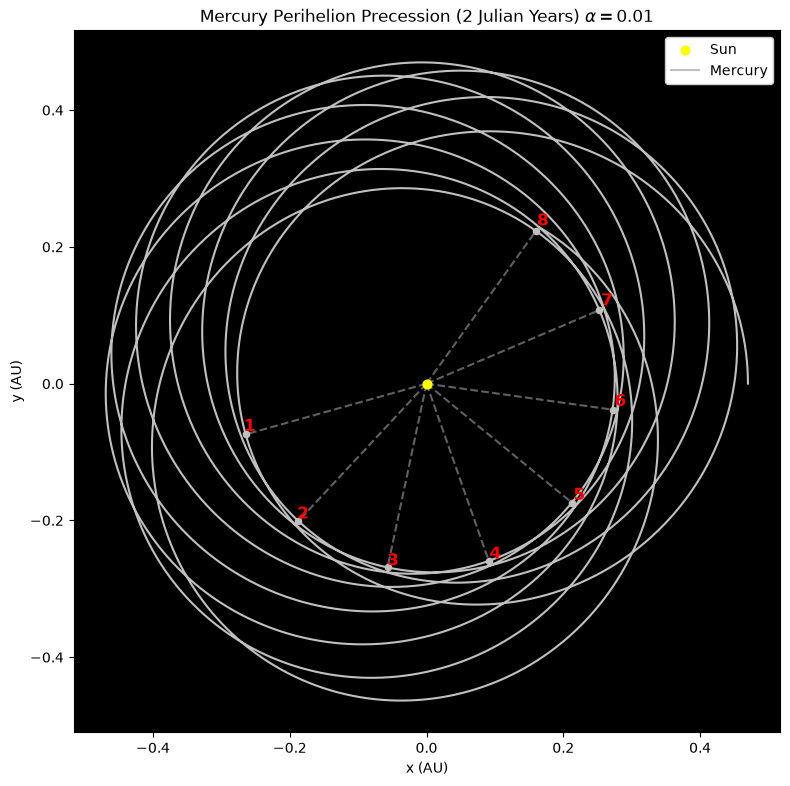

In [4]:
# Cell 04 - Mercury's precessing orbit with numbered perihelion markers

plt.figure("Mercury Orbit", figsize=(8, 8))
plt.gca().set_facecolor("black")

# The Sun at the origin
plt.scatter([0.0], [0.0], c="yellow", s=40, label="Sun", zorder=3)

# Mercury's traced orbit
plt.plot(x, y, c="silver", label="Mercury")

# Mark, connect, and number each perihelion
for orbit_num, k in enumerate(peri_idx, start=1):
    xk, yk = x[k], y[k]
    plt.plot([0.0, xk], [0.0, yk], c="silver", lw=1.5, ls="--", alpha=0.5)
    plt.scatter([xk], [yk], c="silver", s=20, zorder=3)
    plt.text(
        xk * 1.01, yk * 1.01, f"{orbit_num}",
        color="red", fontsize=12, fontweight="bold",
        ha="left", va="bottom", zorder=4,
    )

plt.title(rf"Mercury Perihelion Precession ({tf_demo:.0f} Julian Years) $\alpha={alpha_demo}$")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(framealpha=1.0)
plt.tight_layout()
plt.show()

## Orbital distance over time

The same information appears in a cleaner form if we plot the Sun-Mercury distance
$r$ against time. The curve dips to a minimum once per orbit; each red dot marks a
perihelion. The dips are evenly spaced in time (the orbital *period* is essentially
unchanged), which is what lets us treat the perihelion angle as a clean function of
time in the next plot.

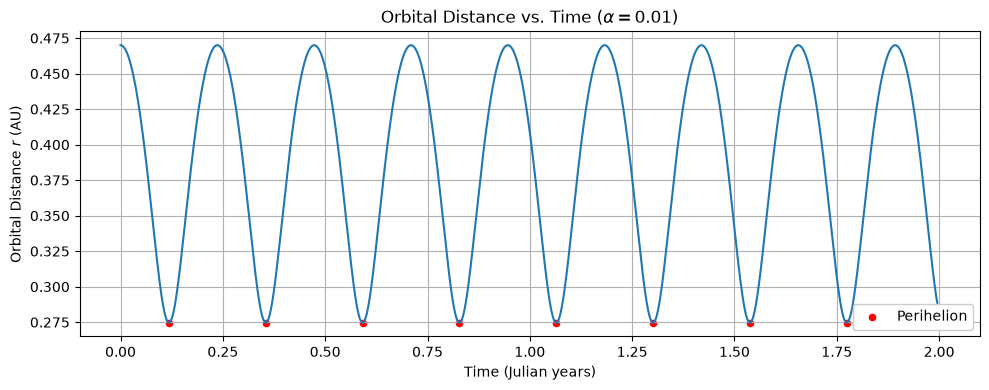

In [5]:
# Cell 05 - Orbital distance vs time

plt.figure("Orbital Distance vs Time", figsize=(10, 4))
plt.plot(t, r)
plt.scatter(t[peri_idx], r[peri_idx], c="red", s=20, label="Perihelion")
plt.title(rf"Orbital Distance vs. Time ($\alpha={alpha_demo}$)")
plt.xlabel("Time (Julian years)")
plt.ylabel(r"Orbital Distance $r$ (AU)")
plt.legend(framealpha=1.0)
plt.grid(True)
plt.tight_layout()
plt.show()

## The precession rate: a straight line in time

Here is the heart of Part 1. We plot each perihelion's (unwrapped) angle against the
time it occurred. The points fall on a **straight line**, and a linear fit gives the
precession rate

$$\frac{d\theta}{dt} \quad\text{(degrees per year)}.$$

The linearity is important: it tells us the perihelion advances by the same amount
every orbit, so a single slope fully characterizes the drift. That slope is the one
number we carry into Part 2. (Remember this value is for the *exaggerated*
$\alpha = 0.01$; the real orbit precesses far more slowly.)

Perihelion precession slope = 132.0838 deg/yr  (at alpha = 0.01)


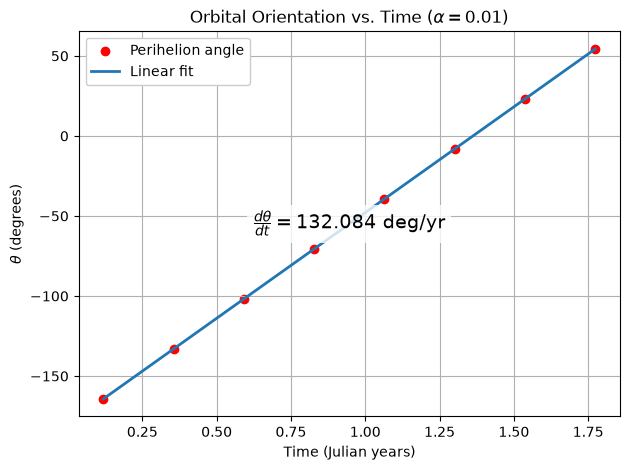

In [6]:
# Cell 06 - Perihelion angle vs time with a linear fit (the precession slope)

slope_demo, intercept_demo = np.polyfit(t[peri_idx], peri_angles, 1)  # deg/yr
y_fit = slope_demo * t[peri_idx] + intercept_demo

print(f"Perihelion precession slope = {slope_demo:.4f} deg/yr  (at alpha = {alpha_demo})")

plt.figure("Orbit Orientation vs Time")
plt.scatter(t[peri_idx], peri_angles, c="red", label="Perihelion angle")
plt.plot(t[peri_idx], y_fit, lw=2, label="Linear fit")
plt.text(
    0.5, 0.5, rf"$\frac{{d\theta}}{{dt}} = {slope_demo:.3f}\ \mathrm{{deg/yr}}$",
    transform=plt.gca().transAxes,
    fontsize=14, ha="center", va="center",
    bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
)
plt.title(rf"Orbital Orientation vs. Time ($\alpha={alpha_demo}$)")
plt.xlabel("Time (Julian years)")
plt.ylabel(r"$\theta$ (degrees)")
plt.legend(framealpha=1.0)
plt.grid(True)
plt.tight_layout()
plt.show()

---
# Part 2 - Extrapolating to the real value

We now have a way to measure a precession rate for any $\alpha$. The strategy for
recovering the real, tiny GR precession is:

1. **Sweep** $\alpha$ across a range of small values and measure the slope
   $d\theta/dt$ for each.
2. **Confirm the relationship is linear.** For a weak perturbation, the precession
   rate is directly proportional to $\alpha$. If the sweep points fall on a straight
   line through the origin, we can trust a linear model.
3. **Evaluate that line at the physical value** $\alpha_{\mathrm{GR}}$, which is far
   smaller than anything we could integrate directly in a short run. This is a
   controlled extrapolation, not a guess: the physics guarantees the linearity.

### Where does $\alpha_{\mathrm{GR}}$ come from?

Matching our $(1 + \alpha/r^2)$ force to the first-order Schwarzschild correction of
general relativity (Goldstein, *Classical Mechanics*, Ch. 3) fixes $\alpha$ in terms
of orbital quantities:

$$\alpha_{\mathrm{GR}} = \frac{3\,GM\,a\,(1 - e^2)}{c^2},$$

where $a$ and $e$ are the semi-major axis and eccentricity of the orbit and $c$ is
the speed of light. We compute $a$ and $e$ from the *simulated* orbit's own initial
conditions (via the vis-viva relation and specific angular momentum), because the
slope we measured belongs to that orbit, not to textbook Mercury. The result is a
minuscule $\alpha_{\mathrm{GR}} \approx 10^{-8}\ \text{AU}^2$.

### Converting to arcseconds per century

The fitted slope is in degrees per year. To reach the traditional unit we multiply
by $3600$ (arcseconds per degree) and by $100$ (years per century):

$$\text{precession} = \frac{d\theta}{dt}\bigg|_{\alpha_{\mathrm{GR}}}
   \times 3600 \times 100 \quad\text{arcsec/century}.$$

The next cell runs the sweep with a plain loop (printing each result as it goes),
replacing the progress bar from the original script.

In [7]:
# Cell 07 - Sweep alpha and measure the precession slope for each


def precession_slope(alpha, tf=2.0):
    """Simulate the orbit for a given alpha and return the slope d(theta)/dt.

    Reuses simulate_orbit and find_perihelia, then fits a line to the
    perihelion angle vs time. Returns the slope in degrees per year.
    """
    t, x, y, r = simulate_orbit(alpha=alpha, tf=tf)
    peri_idx, peri_angles = find_perihelia(t, x, y, r)
    slope, _ = np.polyfit(t[peri_idx], peri_angles, 1)
    return slope


# Sweep 11 small alpha values and record the precession slope of each
alpha_span = np.linspace(0.0001, 0.001, 11)
slopes = np.empty_like(alpha_span)

print(f"{'alpha (AU^2)':>14}   {'slope (deg/yr)':>16}")
print("-" * 34)
for i, alpha in enumerate(alpha_span):
    slopes[i] = precession_slope(alpha)
    print(f"{alpha:>14.5f}   {slopes[i]:>16.4f}")

  alpha (AU^2)     slope (deg/yr)
----------------------------------
       0.00010             1.0304


       0.00019             2.0100


       0.00028             2.9176
       0.00037             3.7654


       0.00046             4.8042


       0.00055             5.7708


       0.00064             6.8162


       0.00073             7.6754
       0.00082             8.6638


       0.00091             9.6935


       0.00100            10.5739


## The extrapolation

Finally we fit a line to the (slope vs $\alpha$) sweep and read it off at
$\alpha_{\mathrm{GR}}$. The scatter points should lie neatly on the fit, confirming
the precession rate really is proportional to the strength of the correction. The
title reports the extrapolated precession of Mercury in **arcseconds per century** -
compare it with the general-relativity target of about **43 arcsec/century** that
Einstein reproduced in 1915. Given the deliberately simplified force model and the
short two-year integrations, landing in the right ballpark is the goal.

Simulated orbit: a = 0.3918 AU, e = 0.1995
alpha_GR        = 1.1142e-08 AU^2
slope at alpha_GR = 1.1876e-04 deg/yr
Estimated precession = 42.7518 arcsec/century
(General relativity target: ~43 arcsec/century)


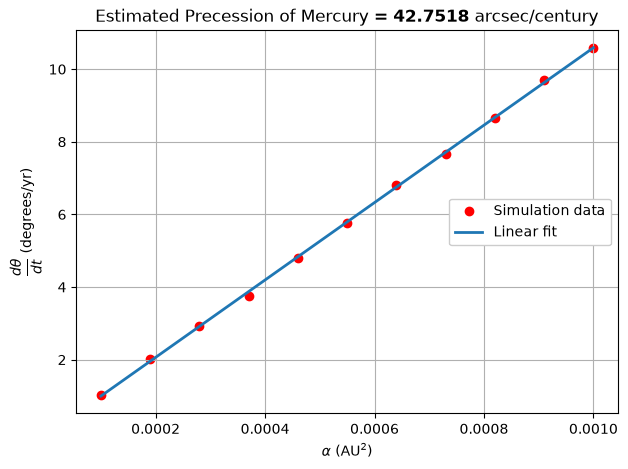

In [8]:
# Cell 08 - Fit slope vs alpha, extrapolate to alpha_GR, report arcsec/century

# Linear model: slope = m * alpha + b
m, b = np.polyfit(alpha_span, slopes, 1)
slope_fit = m * alpha_span + b

# Physical Schwarzschild alpha from the simulated orbit's own elements.
# Recover a (semi-major axis) and e (eccentricity) from the initial conditions
# using vis-viva and specific angular momentum, then apply the GR matching.
c_au_yr = 2.99792458e8 * year_s / AU  # speed of light (AU/yr)
r_sim, v_sim = 0.47, 8.2  # perihelion distance (AU) and speed (AU/yr)
a_sim = 1.0 / (2.0 / r_sim - v_sim**2 / GM)  # vis-viva -> semi-major axis
h_sim = r_sim * v_sim  # specific angular momentum
e_sim = np.sqrt(1.0 - h_sim**2 / (GM * a_sim))  # eccentricity
alpha_GR = 3 * GM * a_sim * (1 - e_sim**2) / c_au_yr**2

# Extrapolate to alpha_GR. The precession rate is PROPORTIONAL to alpha (the line
# passes through the origin: zero correction means zero precession), so we use the
# sweep's slope-per-alpha m and drop the tiny numerical intercept b. Then convert
# deg/yr -> arcsec/century.
slope_at_GR = m * alpha_GR
precession = slope_at_GR * 3_600 * 100  # arcseconds per century

print(f"Simulated orbit: a = {a_sim:.4f} AU, e = {e_sim:.4f}")
print(f"alpha_GR        = {alpha_GR:.4e} AU^2")
print(f"slope at alpha_GR = {slope_at_GR:.4e} deg/yr")
print(f"Estimated precession = {precession:.4f} arcsec/century")
print("(General relativity target: ~43 arcsec/century)")

fig, ax = plt.subplots(num="Precession vs alpha")
ax.set_title(
    "Estimated Precession of Mercury = "
    rf"$\mathbf{{{precession:.4f}}}\ \mathrm{{arcsec/century}}$"
)
ax.scatter(alpha_span, slopes, marker="o", c="r", label="Simulation data")
ax.plot(alpha_span, slope_fit, lw=2, label="Linear fit")
ax.set_xlabel(r"$\alpha$ (AU$^2$)")
ax.set_ylabel(r"$\dfrac{d\theta}{dt}$ (degrees/yr)")
ax.legend(loc="center right", framealpha=1.0, facecolor="white")
ax.grid(True)
fig.tight_layout()
plt.show()